# Firing Rate vs LDA — controlling for trial condition
Session-level PSTH + baseline correlation, but **subsampling a similar number of correct trials per session** before aggregating (optionally balanced across conditions).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, hashlib
from scipy.stats import pearsonr, spearmanr
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white' 

In [2]:
prefix = '/home/ines/repositories/representation_learning_variability/paper-individuality/'
firing_rates_dir = prefix + 'data/firing_rates/'
clustering_dir = prefix + 'clustering/'
trials_path = prefix + '4_mice/all_trials_04-05-2026'

lda = pd.read_pickle(clustering_dir + 'mouse_LDA_5_bins_cut19-06-2026')
lda = lda.rename(columns={0: 'lda_1', 1: 'lda_2'})
lda['binned1'] = lda['binned1'].cat.codes          # interval categories -> 0..4

trials_df = pd.read_parquet(trials_path)            # session, trial_id, correct, contrast, choice, ...

print(f"LDA sessions: {lda['session'].nunique()}")
print(f"Trials table: {trials_df.shape}, correct rate = {trials_df['correct'].mean():.2f}")

LDA sessions: 248
Trials table: (198891, 11), correct rate = 0.82


In [3]:
pkl_files = sorted([f for f in os.listdir(firing_rates_dir) if f.startswith('firing_rate_')])
with open(os.path.join(firing_rates_dir, pkl_files[0]), 'rb') as f:
    sample_data = pickle.load(f)

time_cols = [c for c in sample_data.columns if c.startswith('t_')]
time_cols = sorted(time_cols, key=lambda x: float(x.split('_')[1]))
time_values = np.array([float(c.split('_')[1]) for c in time_cols])

baseline_mask = (time_values >= -0.2) & (time_values <= 0)
baseline_cols = [c for c, m in zip(time_cols, baseline_mask) if m]
print(f"{len(time_cols)} time bins, {time_values.min():.2f}..{time_values.max():.2f}s; "
      f"baseline = {len(baseline_cols)} bins (-0.2..0s)")

90 time bins, -0.50..1.00s; baseline = 12 bins (-0.2..0s)


## Trial-control parameters

In [16]:
# ===========================================================
# TRIAL CONTROL — equalize trials across sessions before aggregating
# ===========================================================
USE_CORRECT_ONLY      = True    # keep only correct trials
N_TARGET              = 200     # trials to subsample per session (min correct/session is ~263)
STRATIFY_BY_CONDITION = True   # if True, sample ~equal trials per condition (stim side x contrast)
SEED                  = 0       # base seed (combined with session id for reproducibility)

# REGION filter (applied to neurons): 'all' | 'drop_root' | 'list'
REGION_MODE   = 'drop_root'
BRAIN_REGIONS = ['CA1', 'DG', 'MRN', 'CP', 'LP', 'CA3']  # ZI PO

# Correct-trial lookup per session (set of trial_ids)
_corr = trials_df[trials_df['correct'] == 1.0] if USE_CORRECT_ONLY else trials_df
correct_by_session = _corr.groupby('session')['trial_id'].apply(set).to_dict()

def session_seed(session):
    """Stable per-session seed so trial choice is reproducible (and equal across probes)."""
    h = int(hashlib.md5(session.encode()).hexdigest()[:8], 16)
    return (h + SEED) % (2**32)

def choose_trials(trial_cond, n_target, seed, stratify):
    """trial_cond: DataFrame of available (correct) trials with columns ['trial_id','condition'].
    Returns an array of chosen trial_ids."""
    if len(trial_cond) <= n_target and not stratify:
        return trial_cond['trial_id'].values
    if stratify:
        n_cond = trial_cond['condition'].nunique()
        per = max(1, n_target // max(1, n_cond))
        picks = []
        for _, g in trial_cond.groupby('condition'):
            picks.append(g.sample(min(per, len(g)), random_state=seed))
        return pd.concat(picks)['trial_id'].values
    return trial_cond.sample(n_target, random_state=seed)['trial_id'].values

print(f"correct-only={USE_CORRECT_ONLY}, N_TARGET={N_TARGET}, stratify={STRATIFY_BY_CONDITION}")

correct-only=True, N_TARGET=200, stratify=True


In [17]:
# Load files -> per-neuron PSTHs after subsampling correct trials per session.
print("Loading + subsampling trials...\n")

bin_map = {s: b for s, b in zip(lda['session'], lda['binned1']) if b >= 0}

neuron_raw_list, neuron_sub_list, meta_list = [], [], []
trials_used = {}   # session -> n trials actually used

for i, pkl_file in enumerate(pkl_files):
    try:
        with open(os.path.join(firing_rates_dir, pkl_file), 'rb') as f:
            data = pickle.load(f)

        session = data['session'].iloc[0]
        b = bin_map.get(session, None)
        if b is None:
            continue

        # --- subsample correct trials for this session ---
        corr_ids = correct_by_session.get(session, None)
        if corr_ids is None:
            continue
        avail = data[['trial_id', 'condition']].drop_duplicates()
        avail = avail[avail['trial_id'].isin(corr_ids)]
        if len(avail) == 0:
            continue
        chosen = choose_trials(avail, N_TARGET, session_seed(session), STRATIFY_BY_CONDITION)
        data = data[data['trial_id'].isin(chosen)]
        trials_used[session] = len(chosen)

        # --- per-neuron PSTH over the kept trials ---
        data['baseline_fr'] = np.nanmean(data[baseline_cols].values, axis=1)
        grp = data.groupby('neuron_id')
        g_raw = grp[time_cols].mean()
        g_bl = grp['baseline_fr'].mean()
        g_sub = g_raw.sub(g_bl, axis=0)

        m = grp.agg(area=('area', 'first'), pid=('pid', 'first')).reset_index()
        m['baseline_fr'] = g_bl.values
        m['session'] = session
        m['bin'] = int(b)

        neuron_raw_list.append(g_raw.values)
        neuron_sub_list.append(g_sub.values)
        meta_list.append(m)

        if (i + 1) % 50 == 0:
            print(f"Processed {i + 1}/{len(pkl_files)} files...")
    except Exception as e:
        print(f"Error loading {pkl_file}: {e}")

neuron_raw_all = np.vstack(neuron_raw_list)
neuron_sub_all = np.vstack(neuron_sub_list)
neuron_meta_all = pd.concat(meta_list, ignore_index=True)

tu = pd.Series(trials_used)
print(f"\n✓ {neuron_raw_all.shape[0]} neurons / {neuron_meta_all['session'].nunique()} sessions")
print(f"  Trials used per session: min={tu.min()}, median={int(tu.median())}, max={tu.max()}")
print(f"  Sessions using < N_TARGET (had fewer correct trials): {(tu < N_TARGET).sum()}")

Loading + subsampling trials...

Processed 50/380 files...
Processed 100/380 files...
Processed 150/380 files...
Processed 200/380 files...
Processed 250/380 files...
Processed 300/380 files...
Processed 350/380 files...

✓ 65374 neurons / 244 sessions
  Trials used per session: min=152, median=183, max=198
  Sessions using < N_TARGET (had fewer correct trials): 244


In [18]:
# Region filter -> defines the neurons entering all analyses below
area = neuron_meta_all['area']
if REGION_MODE == 'all':
    mask = np.ones(len(area), dtype=bool)
elif REGION_MODE == 'drop_root':
    mask = (area != 'root').values
elif REGION_MODE == 'list':
    mask = area.isin(BRAIN_REGIONS).values
else:
    raise ValueError(REGION_MODE)

neuron_raw = neuron_raw_all[mask]
neuron_sub = neuron_sub_all[mask]
neuron_meta = neuron_meta_all[mask].reset_index(drop=True)
print(f"Region '{REGION_MODE}': kept {mask.sum()}/{len(mask)} neurons, "
      f"{neuron_meta['session'].nunique()} sessions")

Region 'drop_root': kept 34658/65374 neurons, 244 sessions


## Session-level PSTH (average within session, SEM across sessions)

In [19]:
# Collapse to one vector per session, then mean +/- SEM across sessions per bin
def mean_sem(mat):
    n = mat.shape[0]
    mean = np.nanmean(mat, axis=0)
    sem = np.nanstd(mat, axis=0, ddof=1) / np.sqrt(n) if n > 1 else np.zeros_like(mean)
    return mean, sem, n

sess_arr = neuron_meta['session'].values
bins_arr = neuron_meta['bin'].values
usess = np.unique(sess_arr)

sess_raw = np.vstack([np.nanmean(neuron_raw[sess_arr == s], axis=0) for s in usess])
sess_sub = np.vstack([np.nanmean(neuron_sub[sess_arr == s], axis=0) for s in usess])
sess_bin = np.array([bins_arr[sess_arr == s][0] for s in usess])

session_stats_raw, session_stats_sub = {}, {}
for b in range(5):
    m = sess_bin == b
    if m.sum() > 0:
        session_stats_raw[b] = mean_sem(sess_raw[m])
        session_stats_sub[b] = mean_sem(sess_sub[m])

print("Sessions per bin:", {b: int((sess_bin == b).sum()) for b in range(5)})

Sessions per bin: {0: 47, 1: 81, 2: 58, 3: 44, 4: 14}


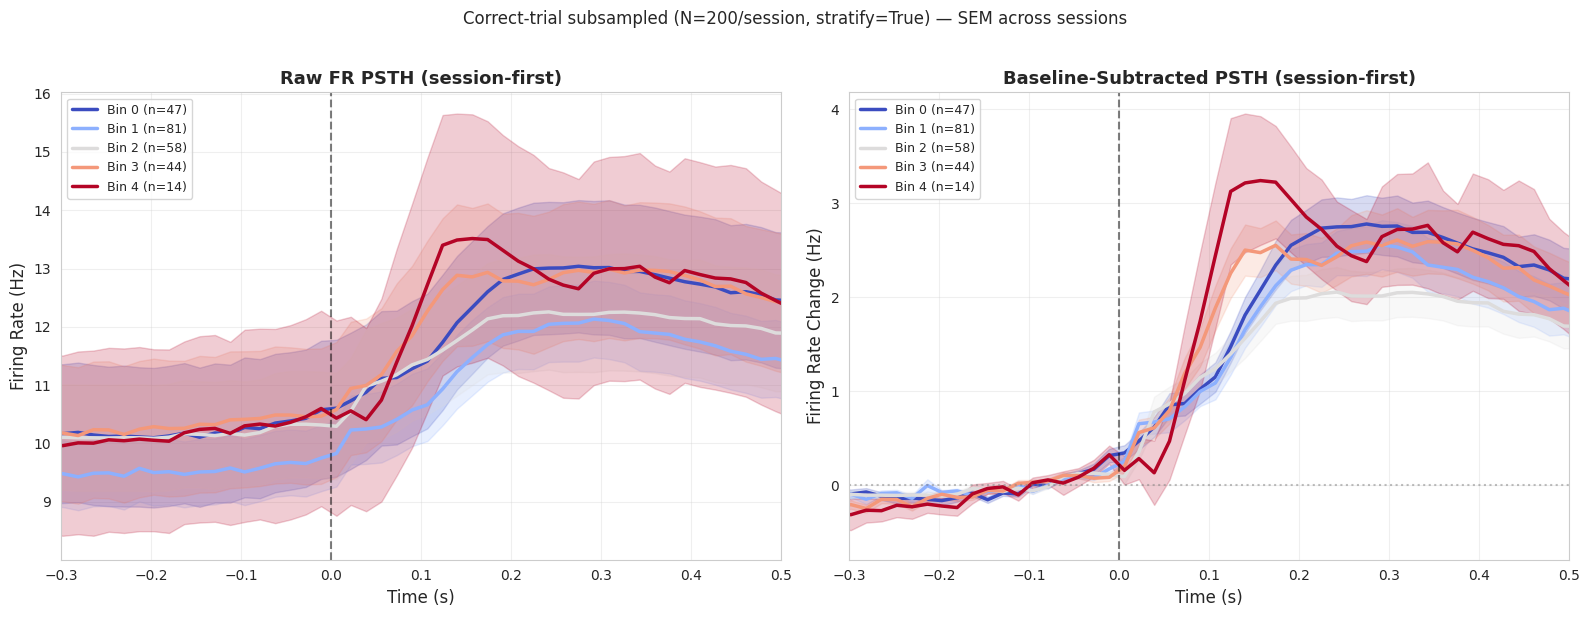

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = plt.cm.coolwarm(np.linspace(0, 1, 5))

for ax, stats_dict, title, ylabel in [
    (axes[0], session_stats_raw, 'Raw FR PSTH (session-first)', 'Firing Rate (Hz)'),
    (axes[1], session_stats_sub, 'Baseline-Subtracted PSTH (session-first)', 'Firing Rate Change (Hz)'),
]:
    for b in range(5):
        if b not in stats_dict:
            continue
        mean, sem, n = stats_dict[b]
        ax.plot(time_values, mean, color=colors[b], linewidth=2.5, label=f'Bin {b} (n={n})')
        ax.fill_between(time_values, mean - sem, mean + sem, color=colors[b], alpha=0.2)
    ax.axvline(0, color='black', linestyle='--', alpha=0.5, linewidth=1.5)
    if 'Subtracted' in title:
        ax.axhline(0, color='gray', linestyle=':', alpha=0.5)
    ax.set_xlabel('Time (s)', fontsize=12); ax.set_ylabel(ylabel, fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3); ax.set_xlim([-0.3, 0.5])

fig.suptitle(f"Correct-trial subsampled (N={N_TARGET}/session, stratify={STRATIFY_BY_CONDITION}) — "
             f"SEM across sessions", fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

## Baseline firing rate vs LDA 1 (session level)

In [21]:
# Session-level baseline FR (mean across neurons of the session), merged with LDA
baseline_session = (neuron_meta.groupby('session', as_index=False)['baseline_fr'].mean()
                    .rename(columns={'baseline_fr': 'baseline_fr_mean'}))
baseline_with_lda = baseline_session.merge(lda[['session', 'lda_1', 'binned1']], on='session', how='inner')

vd = baseline_with_lda[['baseline_fr_mean', 'lda_1']].dropna()
r, p = pearsonr(vd['baseline_fr_mean'], vd['lda_1'])
rho, pp = spearmanr(vd['baseline_fr_mean'], vd['lda_1'])
print("="*60)
print("Baseline FR vs LDA 1  (session level, correct-trial subsampled)")
print("="*60)
print(f"n_sessions={len(vd)}  pearson r={r:+.3f} p={p:.3f}  spearman rho={rho:+.3f} p={pp:.3f}")

Baseline FR vs LDA 1  (session level, correct-trial subsampled)
n_sessions=244  pearson r=+0.052 p=0.415  spearman rho=+0.033 p=0.608


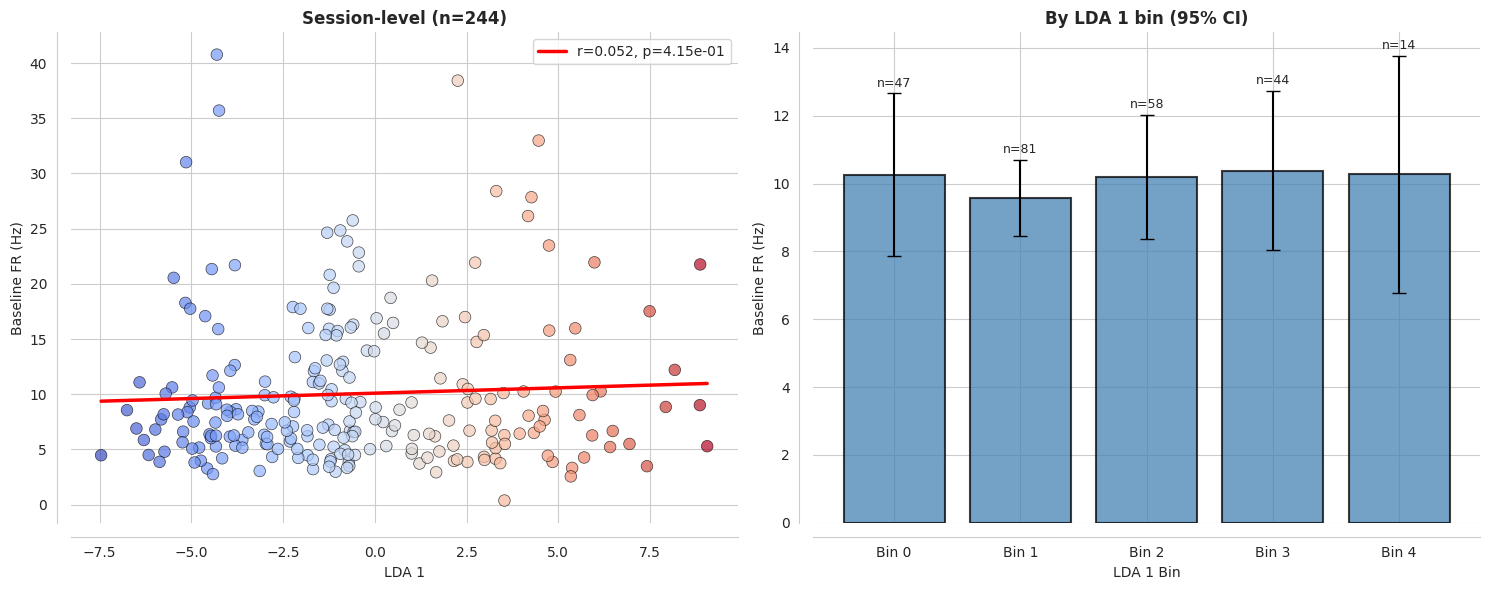

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# scatter + fit
x, y = vd['lda_1'].values, vd['baseline_fr_mean'].values
ax1.scatter(x, y, c=x, cmap='coolwarm', alpha=0.7, s=70, edgecolors='black', linewidth=0.5)
z = np.polyfit(x, y, 1); xl = np.linspace(x.min(), x.max(), 100)
ax1.plot(xl, np.poly1d(z)(xl), 'r-', lw=2.5, label=f'r={r:.3f}, p={p:.2e}')
ax1.set_xlabel('LDA 1'); ax1.set_ylabel('Baseline FR (Hz)')
ax1.set_title(f'Session-level (n={len(vd)})', fontweight='bold'); ax1.legend()
sns.despine(ax=ax1, offset=10)

# bar by bin, 95% CI
bd = baseline_with_lda.groupby('binned1')['baseline_fr_mean'].agg(['mean', 'std', 'count'])
bd['ci95'] = bd.apply(lambda r_: stats.t.ppf(0.975, r_['count']-1) * r_['std']/np.sqrt(r_['count'])
                      if r_['count'] > 1 else 0.0, axis=1)
xp = np.arange(len(bd))
ax2.bar(xp, bd['mean'], yerr=bd['ci95'], capsize=5, alpha=0.75, color='steelblue',
        edgecolor='black', linewidth=1.5)
ax2.set_xticks(xp); ax2.set_xticklabels([f'Bin {i}' for i in bd.index])
ax2.set_xlabel('LDA 1 Bin'); ax2.set_ylabel('Baseline FR (Hz)')
ax2.set_title('By LDA 1 bin (95% CI)', fontweight='bold')
for i, (mn, ci, c) in enumerate(zip(bd['mean'], bd['ci95'], bd['count'])):
    ax2.text(i, mn + ci + 0.2, f'n={int(c)}', ha='center', fontsize=9)
sns.despine(ax=ax2, offset=10)

plt.tight_layout(); plt.show()